# Cairo Tourist Attractions — Data Cleaning & EDA
**Dataset:** Cairo_Tourist_Attractions.csv  
**Tools:** pandas · numpy · matplotlib · seaborn

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, re

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 5)})

## Step 1 — Load & Inspect Data

In [ ]:
# ## Step 1 — Load & Inspect
# --------------------------------------------------------------------------
# The CSV uses a multi-line quoting style; engine='python' + quoting=3 gives
# us the most forgiving parse for the messy address / opening-hours fields.
# --------------------------------------------------------------------------
RAW_PATH  = 'D:\Scraping\Cairo Tourist Attractions - Sheet1 (1).csv'
SAVE_PATH = 'Cairo_Tourist_Attractions_Cleaned.csv'

df_raw = pd.read_csv(RAW_PATH, engine='python', on_bad_lines='skip')

print('── First 5 rows ──────────────────────────────────────────────────────')
display(df_raw.head())

print(f'\n── Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

print('\n── Column names ──────────────────────────────────────────────────────')
print(df_raw.columns.tolist())

print('\n── Data types ────────────────────────────────────────────────────────')
print(df_raw.dtypes)

print('\n── Missing values (count & %) ────────────────────────────────────────')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
display(pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
          .query('Missing > 0').sort_values('Missing', ascending=False))

print(f'\n── Exact duplicate rows: {df_raw.duplicated().sum()}')

── First 5 rows ──────────────────────────────────────────────────────


,Category,Name,Rating,Review Count,Price Range,Address,Phone,Website,Opening Hours,Description,Photo URLs,Latitude,Longitude,Google Maps URL
0,Landmark,برج القاهرة,4.3,29908.0,NaN,\nشارع قصر النيل، الزمالك، محافظة القاهرة‬ 42...,227365112.0,NaN,مغلق · يفتح عند الساعة ٩ ص,برج على شكل زهرة اللوتس تكسوه 8 ملايين حجر فسي...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...
1,Landmark,ميدان طلعت حرب,4.5,22548.0,NaN,\nشارع طلعت حرب، باب اللوق، قسم قصر النيل، مح...,NaN,NaN,مفتوح على مدار الساعة,تقاطع طرق رئيسي يضمّ تمثالاً يحمل رمزًا وطنيًا...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...
2,Landmark,ميدان التحرير,4.6,5206.0,NaN,\nميدان التحرير، محطة السادات، قسم قصر النيل،...,NaN,NaN,NaN,إضافة رقم الهاتف للمكان,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...
3,Landmark,باب زويلة,4.7,2895.0,NaN,\n27V5+545، محمد علي، الدرب الأحمر، محافظة ال...,NaN,https://www.archnet.org/sites/2728,مفتوح على مدار الساعة,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...
4,Landmark,قلعة صلاح الدين,4.6,35069.0,NaN,NaN,225121735.0,https://egymonuments.gov.eg/ar/archaeological-...,NaN,حصن مهيب وجدار بناه صلاح الدين في القرن الـ12 ...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...



── Shape: 1050 rows × 14 columns

── Column names ──────────────────────────────────────────────────────
['Category', 'Name', 'Rating', 'Review Count', 'Price Range', 'Address', 'Phone', 'Website', 'Opening Hours', 'Description', 'Photo URLs', 'Latitude', 'Longitude', 'Google Maps URL']

── Data types ────────────────────────────────────────────────────────
Category            object
Name                object
Rating             float64
Review Count       float64
Price Range         object
Address             object
Phone              float64
Website             object
Opening Hours       object
Description         object
Photo URLs          object
Latitude           float64
Longitude          float64
Google Maps URL     object
dtype: object

── Missing values (count & %) ────────────────────────────────────────


,Missing,Missing %
Price Range,998,95.05
Description,820,78.10
Website,531,50.57
Phone,348,33.14
Opening Hours,300,28.57
Address,45,4.29
Rating,41,3.90
Review Count,41,3.90



── Exact duplicate rows: 0


## Step 2 — Data Cleaning

In [ ]:
# ## Step 2 — Data Cleaning
df = df_raw.copy()

# ── 2.1  Standardise column names (lowercase + underscores) ────────────────
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'[\s\-/]+', '_', regex=True)
      .str.replace(r'[^\w]', '', regex=True)
)
print('Cleaned column names:', df.columns.tolist())

# Rename for convenience
df.rename(columns={
    'review_count': 'review_count',
    'price_range' : 'price_range',
    'photo_urls'  : 'photo_urls',
    'google_maps_url': 'maps_url'
}, inplace=True)

# ── 2.2  Fix numeric types ──────────────────────────────────────────────────
df['rating']       = pd.to_numeric(df['rating'],       errors='coerce')
df['review_count'] = pd.to_numeric(df['review_count'], errors='coerce')
df['latitude']     = pd.to_numeric(df['latitude'],     errors='coerce')
df['longitude']    = pd.to_numeric(df['longitude'],    errors='coerce')

# ── 2.3  Fix text columns ───────────────────────────────────────────────────
str_cols = ['category', 'name', 'price_range', 'address',
            'phone', 'website', 'description']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# Standardise category to title-case then strip
df['category'] = df['category'].str.strip().str.title()

# ── 2.4  Remove exact duplicates ───────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} exact duplicate rows. Remaining: {len(df)}')

# ── 2.5  Rating sanity clip (valid range 0–5) ───────────────────────────────
invalid_ratings = df[(df['rating'] < 0) | (df['rating'] > 5)].shape[0]
df.loc[(df['rating'] < 0) | (df['rating'] > 5), 'rating'] = np.nan
print(f'Clipped {invalid_ratings} out-of-range ratings to NaN')

print('\n── Dtypes after cleaning ─────────────────────────────────────────────')
print(df.dtypes)

Cleaned column names: ['category', 'name', 'rating', 'review_count', 'price_range', 'address', 'phone', 'website', 'opening_hours', 'description', 'photo_urls', 'latitude', 'longitude', 'google_maps_url']
Removed 0 exact duplicate rows. Remaining: 1050
Clipped 0 out-of-range ratings to NaN

── Dtypes after cleaning ─────────────────────────────────────────────
category          object
name              object
rating           float64
review_count     float64
price_range       object
address           object
phone             object
website           object
opening_hours     object
description       object
photo_urls        object
latitude         float64
longitude        float64
maps_url          object
dtype: object


In [ ]:
# find duplicated place names
duplicates = df[df.duplicated(subset='place_name', keep=False)]

if duplicates.empty:
    print("No duplicate place names found ✅")
else:
    print("Duplicate place names found ❗")
    print(duplicates[['place_name']].sort_values(by='place_name'))

: 

In [ ]:
duplicate_counts = df['place_name'].value_counts()

repeated_places = duplicate_counts[duplicate_counts > 1]

print("Repeated places with counts:")
print(repeated_places)

## Step 3 — Merge Duplicate Landmarks

In [ ]:
# ## Step 3 — Merge Duplicate Landmarks
# --------------------------------------------------------------------------
# Grouping key: normalised landmark name
#   • category     → unique values joined as comma-separated string
#   • rating       → mean  (arithmetic average is most representative)
#   • review_count → SUM   (total crowd engagement across all duplicates)
#   • other cols   → first non-null value
# --------------------------------------------------------------------------

# Normalise the name key for grouping (lowercase, strip extra spaces)
df['name_key'] = df['name'].str.lower().str.strip()

def first_non_null(s):
    """Return first non-null, non-empty value in a Series."""
    valid = s.dropna()
    return valid.iloc[0] if len(valid) > 0 else np.nan

def merge_categories(s):
    """Combine all category values: lowercase, deduplicate, return comma-sep string."""
    cats = (
        s.dropna()
         .astype(str)
         .str.lower()
         .str.strip()
         .unique()
    )
    return ', '.join(sorted(set(cats))) if len(cats) > 0 else np.nan

# Columns that will be kept 'first non-null'
passthrough_cols = [c for c in df.columns
                    if c not in ['name', 'name_key', 'category',
                                 'rating', 'review_count']]

agg_dict = {'category': merge_categories,
            'rating'  : 'mean',
            'review_count': 'sum'}
agg_dict.update({c: first_non_null for c in passthrough_cols})

df_merged = (
    df.groupby('name_key', sort=False)
      .agg(agg_dict)
      .reset_index()
)

# Re-attach the display name (original casing, first occurrence)
name_map = df.groupby('name_key')['name'].first()
df_merged['name'] = df_merged['name_key'].map(name_map)
df_merged.drop(columns='name_key', inplace=True)

# Round rating to 2 decimal places
df_merged['rating'] = df_merged['rating'].round(2)

print(f'Before merge: {len(df)} rows')
print(f'After  merge: {len(df_merged)} unique landmarks')
print(f'Collapsed   : {len(df) - len(df_merged)} duplicate rows')

# Confirm no duplicate names remain
dups_after = df_merged['name'].str.lower().str.strip().duplicated().sum()
print(f'\n✅ Duplicate landmark names remaining: {dups_after}')

display(df_merged.head())

Before merge: 1050 rows
After  merge: 1050 unique landmarks
Collapsed   : 0 duplicate rows

✅ Duplicate landmark names remaining: 0


,category,rating,review_count,price_range,address,phone,website,opening_hours,description,photo_urls,latitude,longitude,maps_url,name
0,landmark,4.3,29908.0,NaN,\nشارع قصر النيل، الزمالك، محافظة القاهرة‬ 42...,227365112.0,NaN,مغلق · يفتح عند الساعة ٩ ص,برج على شكل زهرة اللوتس تكسوه 8 ملايين حجر فسي...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...,برج القاهرة
1,landmark,4.5,22548.0,NaN,\nشارع طلعت حرب، باب اللوق، قسم قصر النيل، مح...,NaN,NaN,مفتوح على مدار الساعة,تقاطع طرق رئيسي يضمّ تمثالاً يحمل رمزًا وطنيًا...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...,ميدان طلعت حرب
2,landmark,4.6,5206.0,NaN,\nميدان التحرير، محطة السادات، قسم قصر النيل،...,NaN,NaN,NaN,إضافة رقم الهاتف للمكان,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...,ميدان التحرير
3,landmark,4.7,2895.0,NaN,\n27V5+545، محمد علي، الدرب الأحمر، محافظة ال...,NaN,https://www.archnet.org/sites/2728,مفتوح على مدار الساعة,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...,باب زويلة
4,landmark,4.6,35069.0,NaN,NaN,225121735.0,https://egymonuments.gov.eg/ar/archaeological-...,NaN,حصن مهيب وجدار بناه صلاح الدين في القرن الـ12 ...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...,قلعة صلاح الدين


## Step 4 — Feature Engineering

In [ ]:
# ## Step 4 — Feature Engineering

# ── 4.1  Number of categories per landmark ─────────────────────────────────
def count_categories(cat_str):
    if pd.isna(cat_str):
        return 0
    return len([c for c in str(cat_str).split(',') if c.strip()])

df_merged['num_categories'] = df_merged['category'].apply(count_categories)

# ── 4.2  Explode categories → deduplicated, title-cased list ───────────────
def clean_cat_list(cat_str):
    """Return a sorted, deduplicated, title-cased list of categories."""
    if pd.isna(cat_str):
        return np.nan
    cats = [c.strip().title() for c in str(cat_str).split(',') if c.strip()]
    return ', '.join(sorted(set(cats)))

df_merged['category'] = df_merged['category'].apply(clean_cat_list)

print('Sample of engineered features:')
display(df_merged[['name', 'category', 'num_categories']].head(10))

print(f'\nMax categories on one landmark : {df_merged["num_categories"].max()}')
print(f'Avg categories per landmark    : {df_merged["num_categories"].mean():.2f}')

Sample of engineered features:


,name,category,num_categories
0,برج القاهرة,Landmark,1
1,ميدان طلعت حرب,Landmark,1
2,ميدان التحرير,Landmark,1
3,باب زويلة,Landmark,1
4,قلعة صلاح الدين,Landmark,1
5,تمثال كوبري قصر النيل,Landmark,1
6,باب النصر,Landmark,1
7,باب الفتوح,Landmark,1
8,قصر الأمير محمد علي بالمنيل,Landmark,1
9,قصر حبيب باشا السكاكيني قصر,Landmark,1



Max categories on one landmark : 1
Avg categories per landmark    : 1.00


## Step 5 — Exploratory Data Analysis (EDA)

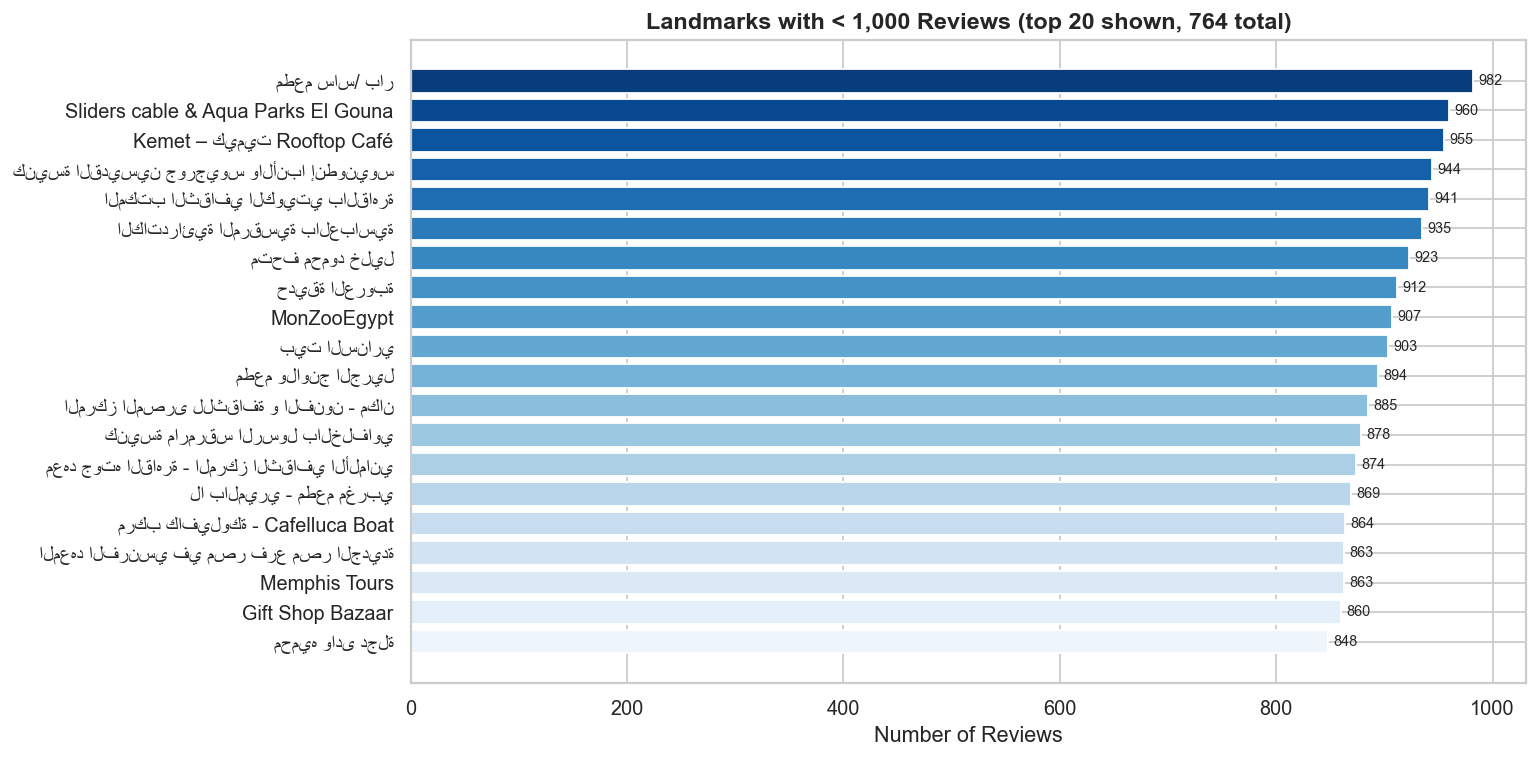

Total landmarks with < 1,000 reviews: 764


In [ ]:
# ## Step 5.1 — Landmarks with fewer than 1,000 reviews
low_review = df_merged[df_merged['review_count'] < 1000].copy()
low_review_sorted = low_review.sort_values('review_count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(low_review_sorted['name'], low_review_sorted['review_count'],
               color=sns.color_palette('Blues_r', len(low_review_sorted)))
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title(f'Landmarks with < 1,000 Reviews (top 20 shown, {len(low_review)} total)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print(f'Total landmarks with < 1,000 reviews: {len(low_review)}')

Overall average rating across all landmarks: 4.439 / 5.0


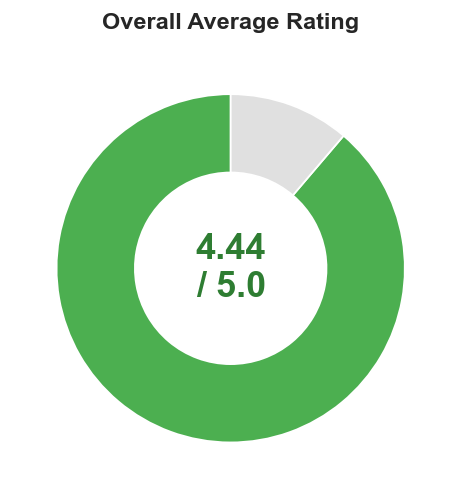

In [ ]:
# ## Step 5.2 — Overall Average Rating
avg_rating = df_merged['rating'].mean()
print(f'Overall average rating across all landmarks: {avg_rating:.3f} / 5.0')

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie([avg_rating, 5 - avg_rating],
       colors=['#4CAF50', '#E0E0E0'],
       startangle=90,
       wedgeprops=dict(width=0.45, edgecolor='white'))
ax.text(0, 0, f'{avg_rating:.2f}\n/ 5.0', ha='center', va='center',
        fontsize=20, fontweight='bold', color='#2e7d32')
ax.set_title('Overall Average Rating', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

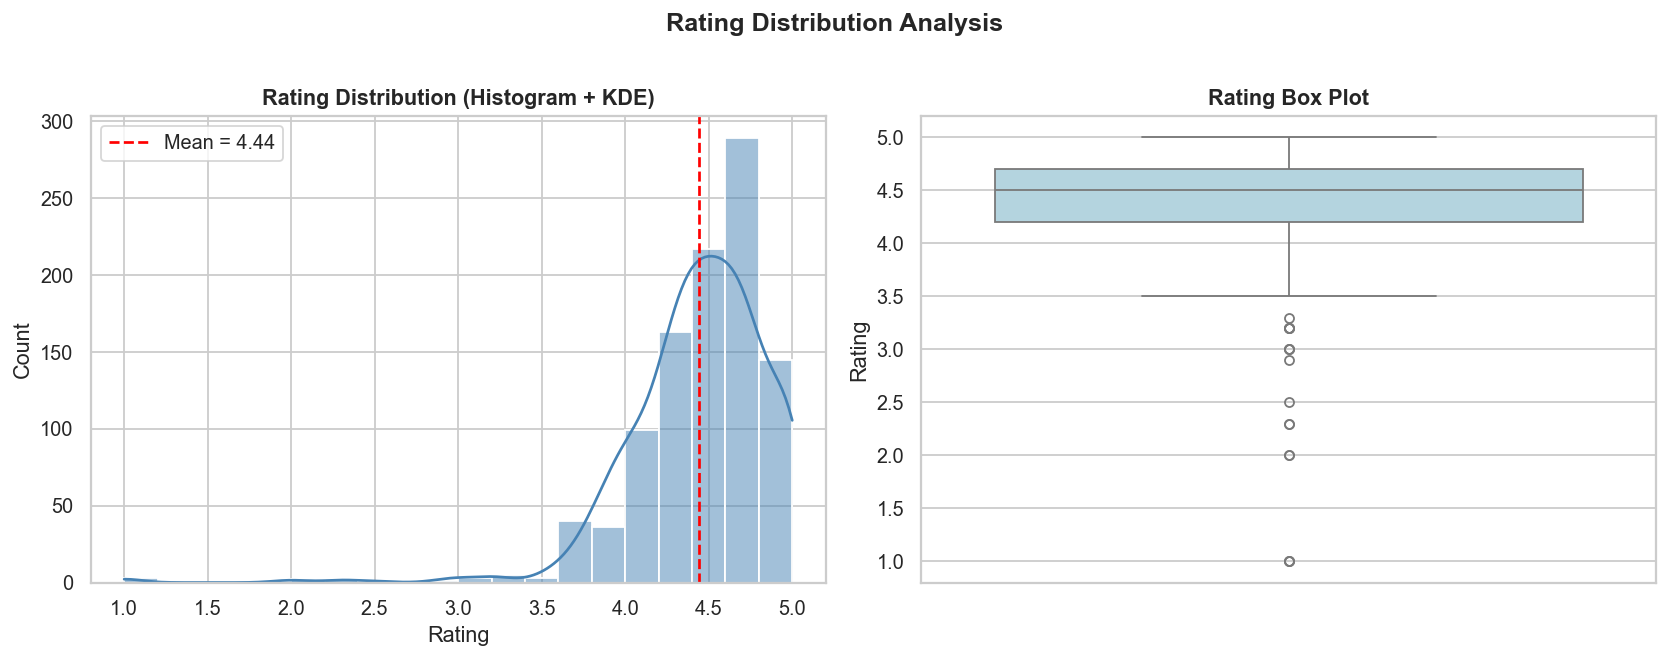

count    1009.000
mean        4.439
std         0.435
min         1.000
25%         4.200
50%         4.500
75%         4.700
max         5.000
Name: rating, dtype: float64


In [ ]:
# ## Step 5.3 — Distribution of Ratings
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram + KDE
sns.histplot(df_merged['rating'].dropna(), bins=20, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(avg_rating, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {avg_rating:.2f}')
axes[0].set_title('Rating Distribution (Histogram + KDE)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(y=df_merged['rating'].dropna(), color='lightblue', ax=axes[1],
            flierprops=dict(marker='o', color='red', markersize=5))
axes[1].set_title('Rating Box Plot', fontweight='bold')
axes[1].set_ylabel('Rating')

plt.suptitle('Rating Distribution Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(df_merged['rating'].describe().round(3))

In [ ]:
# ## Step 5.4 — All Unique Categories
all_cats = (
    df_merged['category']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
)
unique_cats = sorted(all_cats.unique())
print(f'Total unique categories: {len(unique_cats)}')
print('\nAll unique categories:')
for i, c in enumerate(unique_cats, 1):
    print(f'  {i:2d}. {c}')

Total unique categories: 27

All unique categories:
   1. Activity
   2. Ancient Monument
   3. Antiques
   4. Art Gallery
   5. Bazaar / Souq
   6. Coptic Site
   7. Cultural Center
   8. Day Trip Site
   9. Escape Room
  10. Food Tour
  11. Gold & Jewelry Market
  12. Horse Riding
  13. Islamic Monument
  14. Landmark
  15. Museum
  16. Nature Reserve
  17. Nile Cruise
  18. Nile View Restaurant
  19. Park / Garden
  20. Pharaonic Site
  21. Rooftop Restaurant
  22. Shopping Mall
  23. Souvenir Shop
  24. Sport & Recreation
  25. Theme Park
  26. Traditional Restaurant
  27. Zoo / Aquarium


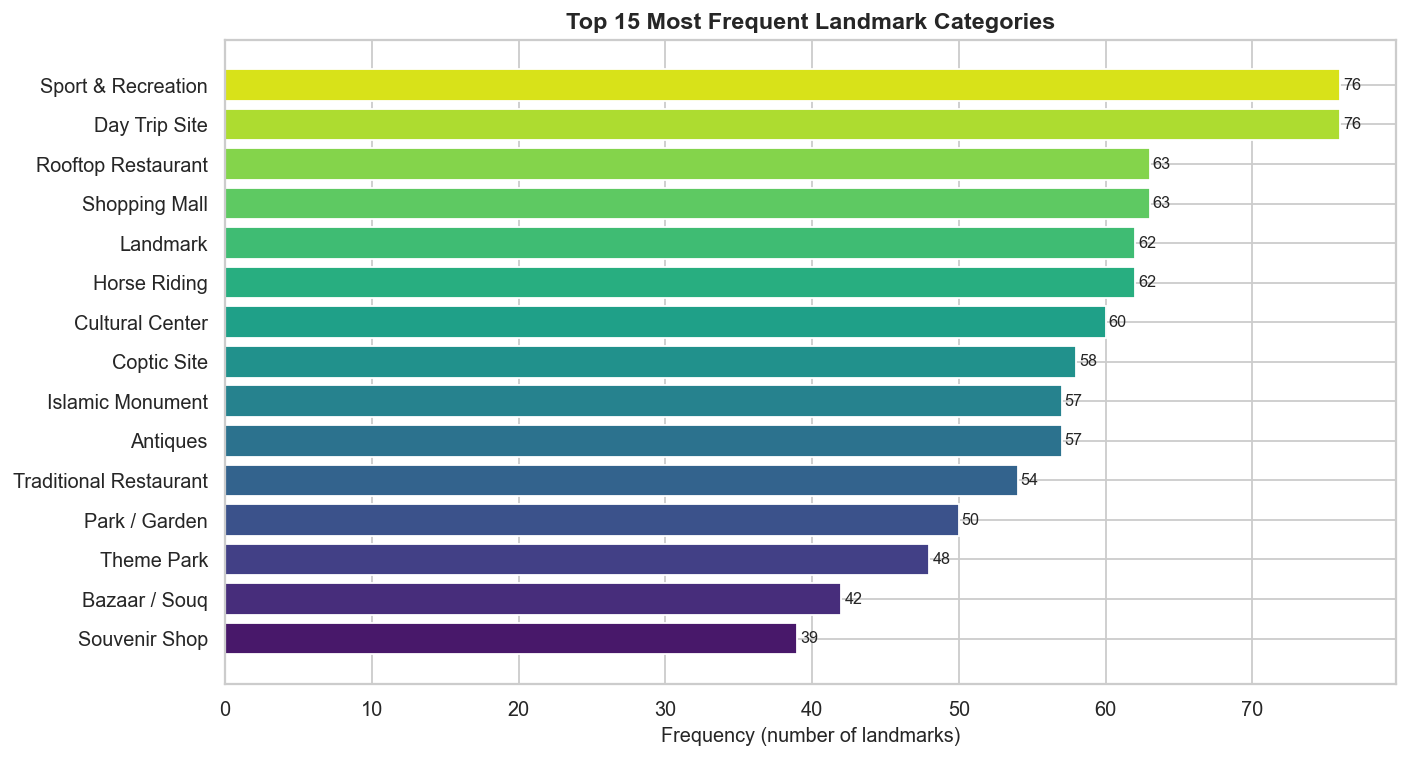

In [ ]:
# ## Step 5.5 — Most Frequent Categories
cat_freq = all_cats.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('viridis', len(cat_freq))
bars = ax.barh(cat_freq.index[::-1], cat_freq.values[::-1], color=palette)
ax.set_xlabel('Frequency (number of landmarks)', fontsize=11)
ax.set_title('Top 15 Most Frequent Landmark Categories', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.show()

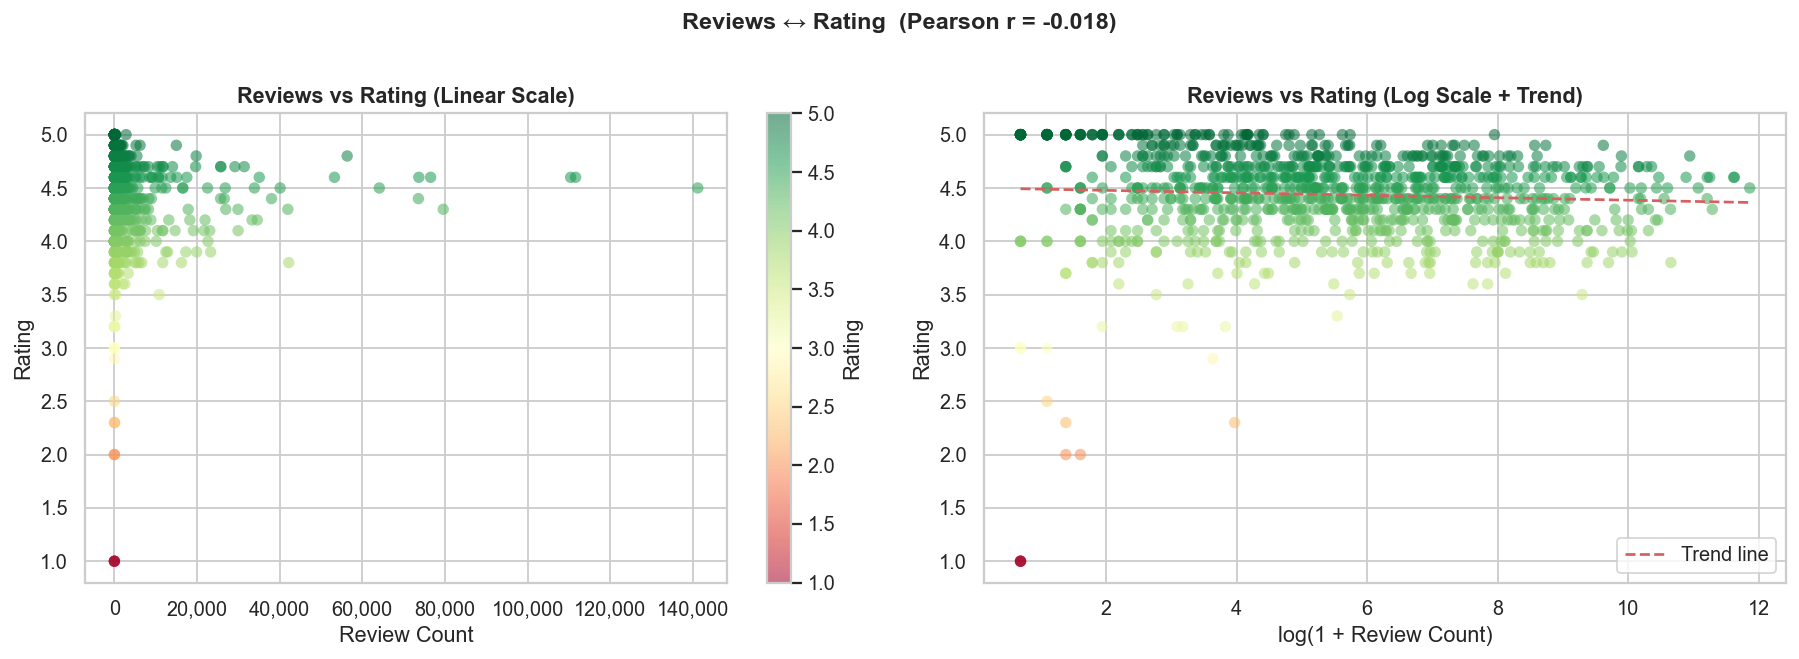

Pearson correlation (reviews vs rating): -0.0176


In [ ]:
# ## Step 5.6 — Reviews vs Rating Relationship
plot_df = df_merged[df_merged['review_count'].notna() & df_merged['rating'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter (raw scale)
sc = axes[0].scatter(plot_df['review_count'], plot_df['rating'],
                     alpha=0.55, c=plot_df['rating'],
                     cmap='RdYlGn', edgecolors='none', s=40)
plt.colorbar(sc, ax=axes[0], label='Rating')
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Rating')
axes[0].set_title('Reviews vs Rating (Linear Scale)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Scatter (log scale for reviews)
axes[1].scatter(np.log1p(plot_df['review_count']), plot_df['rating'],
                alpha=0.55, c=plot_df['rating'],
                cmap='RdYlGn', edgecolors='none', s=40)
# Trend line
z = np.polyfit(np.log1p(plot_df['review_count']).dropna(),
               plot_df.loc[plot_df['review_count'].notna(), 'rating'], 1)
p = np.poly1d(z)
x_fit = np.linspace(np.log1p(plot_df['review_count']).min(),
                    np.log1p(plot_df['review_count']).max(), 200)
axes[1].plot(x_fit, p(x_fit), 'r--', linewidth=1.5, label='Trend line')
axes[1].set_xlabel('log(1 + Review Count)')
axes[1].set_ylabel('Rating')
axes[1].set_title('Reviews vs Rating (Log Scale + Trend)', fontweight='bold')
axes[1].legend()

corr = plot_df['review_count'].corr(plot_df['rating'])
plt.suptitle(f'Reviews ↔ Rating  (Pearson r = {corr:.3f})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'Pearson correlation (reviews vs rating): {corr:.4f}')

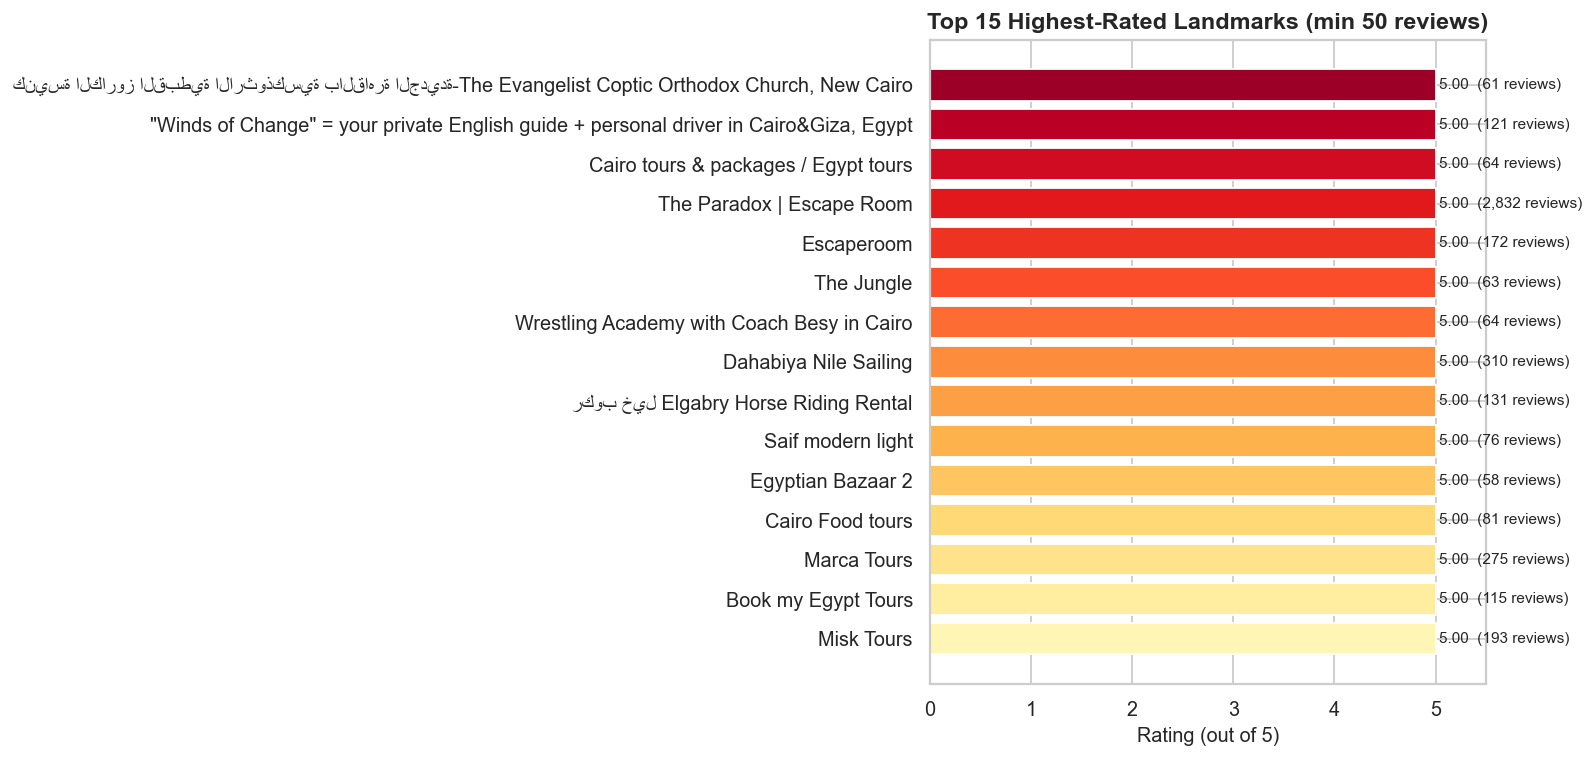

,name,rating,review_count,category
0,كنيسة الكاروز القبطية الارثوذكسية بالقاهرة الج...,5.0,61.0,Coptic Site
1,"""Winds of Change"" = your private English guide...",5.0,121.0,Activity
2,Cairo tours & packages / Egypt tours,5.0,64.0,Activity
3,The Paradox | Escape Room,5.0,2832.0,Escape Room
4,Escaperoom,5.0,172.0,Escape Room
5,The Jungle,5.0,63.0,Sport & Recreation
6,Wrestling Academy with Coach Besy in Cairo,5.0,64.0,Sport & Recreation
7,Dahabiya Nile Sailing,5.0,310.0,Nile Cruise
8,ركوب خيل Elgabry Horse Riding Rental,5.0,131.0,Horse Riding
9,Saif modern light,5.0,76.0,Antiques


In [ ]:
# ## Step 5.7 — Top-Rated Landmarks (min 50 reviews to avoid noise)
top_rated = (
    df_merged[df_merged['review_count'] >= 50]
    .nlargest(15, 'rating')[['name', 'rating', 'review_count', 'category']]
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('YlOrRd', len(top_rated))
bars = ax.barh(top_rated['name'], top_rated['rating'], color=colors[::-1])
ax.set_xlim(0, 5.5)
ax.set_xlabel('Rating (out of 5)', fontsize=11)
ax.set_title('Top 15 Highest-Rated Landmarks (min 50 reviews)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, (_, row) in zip(bars, top_rated.iterrows()):
    ax.text(bar.get_width() + 0.03,
            bar.get_y() + bar.get_height()/2,
            f"{row['rating']:.2f}  ({int(row['review_count']):,} reviews)",
            va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

display(top_rated.reset_index(drop=True))

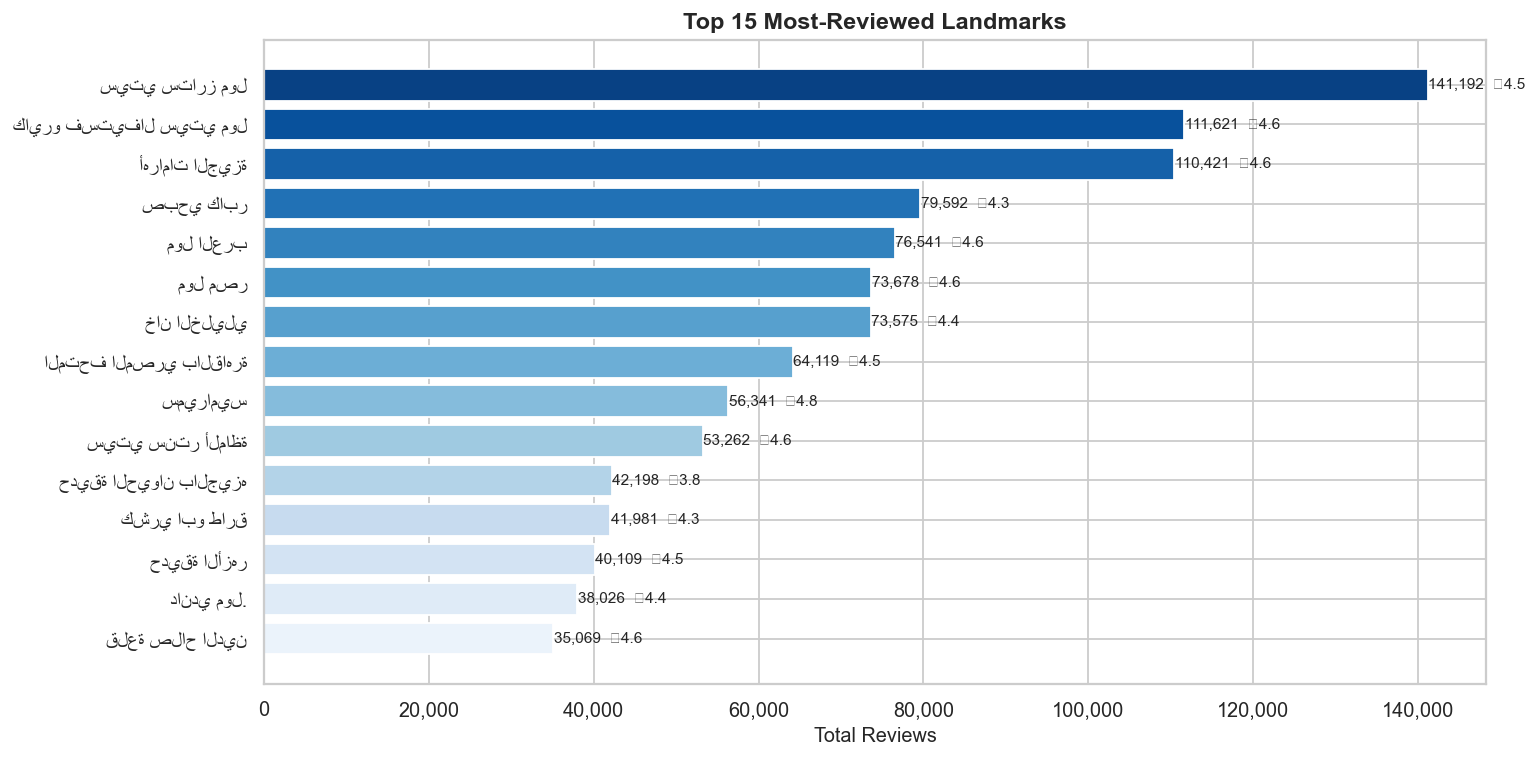

,name,review_count,rating
0,سيتي ستارز مول,141192.0,4.5
1,كايرو فستيفال سيتي مول,111621.0,4.6
2,أهرامات الجيزة,110421.0,4.6
3,صبحي كابر,79592.0,4.3
4,مول العرب,76541.0,4.6
5,مول مصر,73678.0,4.6
6,خان الخليلي,73575.0,4.4
7,المتحف المصري بالقاهرة,64119.0,4.5
8,سميراميس,56341.0,4.8
9,سيتي سنتر ألماظة,53262.0,4.6


In [ ]:
# ## Step 5.8 — Most-Reviewed Landmarks
most_reviewed = df_merged.nlargest(15, 'review_count')[['name', 'review_count', 'rating']]

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('Blues_r', len(most_reviewed))
bars = ax.barh(most_reviewed['name'], most_reviewed['review_count'], color=palette)
ax.set_xlabel('Total Reviews', fontsize=11)
ax.set_title('Top 15 Most-Reviewed Landmarks', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, (_, row) in zip(bars, most_reviewed.iterrows()):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f"{int(row['review_count']):,}  ★{row['rating']:.1f}",
            va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

display(most_reviewed.reset_index(drop=True))

## Step 6 — Data Quality Checks

── IQR Outlier Check ────────────────────────────────────────────────
rating      : 17 outliers  (bounds [3.45, 5.45])
review_count: 167 outliers  (bounds [-1625.75, 2782.25])


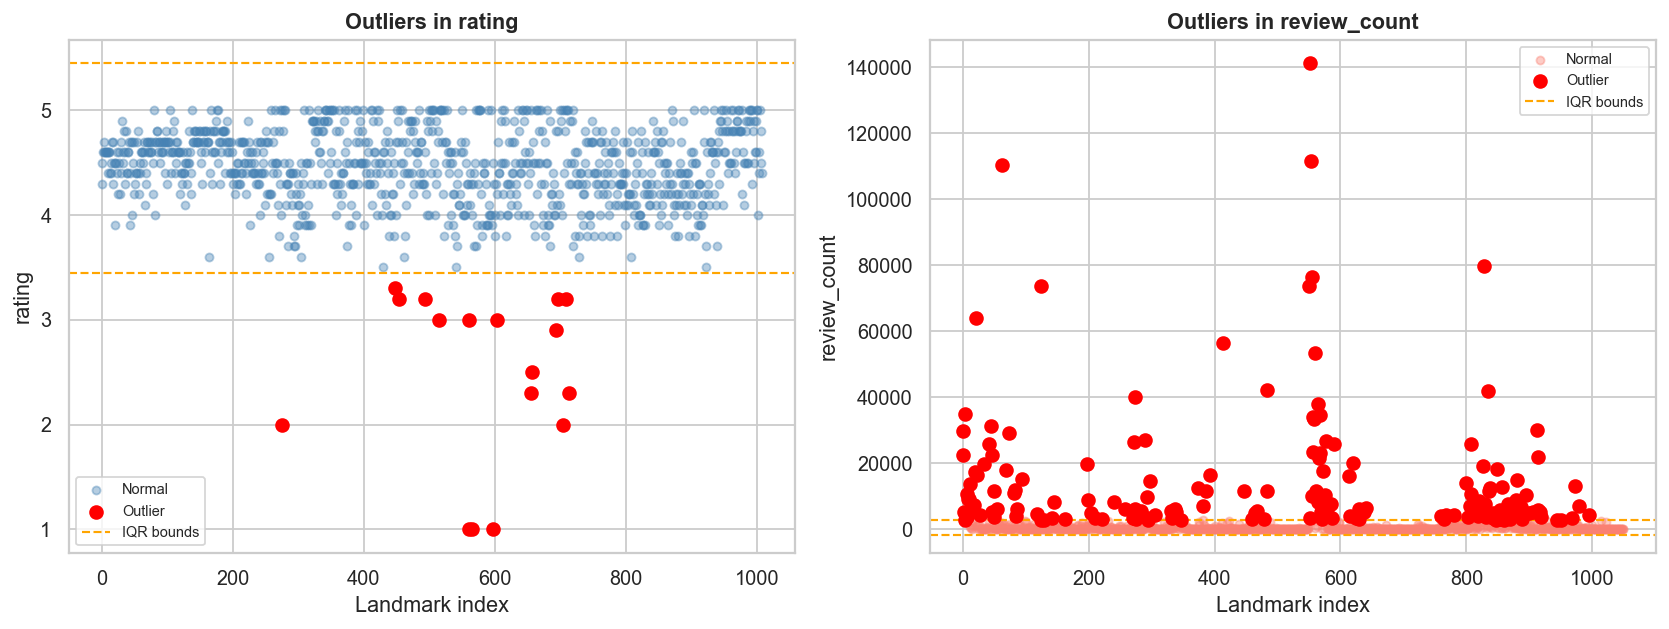


── Duplicate landmark names after merge: 0  (✅ PASS)

── Inconsistent category casings found: 0
✅  All category names are consistently cased.


In [ ]:
# ## Step 6 — Data Quality Checks

# ── 6.1  Outlier Detection (IQR method) ────────────────────────────────────
def iqr_outliers(series, label):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out = series[(series < lower) | (series > upper)]
    print(f'{label}: {len(out)} outliers  '
          f'(bounds [{lower:.2f}, {upper:.2f}])')
    return lower, upper

print('── IQR Outlier Check ────────────────────────────────────────────────')
r_lo, r_hi  = iqr_outliers(df_merged['rating'],       'rating      ')
rv_lo, rv_hi = iqr_outliers(df_merged['review_count'], 'review_count')

# Visualise outliers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, lo, hi, color in [
    (axes[0], 'rating',       r_lo,  r_hi,  'steelblue'),
    (axes[1], 'review_count', rv_lo, rv_hi, 'salmon')
]:
    s = df_merged[col].dropna()
    ax.scatter(range(len(s)), s.values, alpha=0.4, color=color,
               s=20, label='Normal')
    mask = (s < lo) | (s > hi)
    ax.scatter(np.where(mask)[0], s[mask].values,
               color='red', s=50, zorder=5, label='Outlier')
    ax.axhline(lo, color='orange', linestyle='--', linewidth=1.2, label='IQR bounds')
    ax.axhline(hi, color='orange', linestyle='--', linewidth=1.2)
    ax.set_title(f'Outliers in {col}', fontweight='bold')
    ax.set_xlabel('Landmark index')
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 6.2  No duplicate landmark names remain ──────────────────────────────
dup_count = df_merged['name'].str.lower().str.strip().duplicated().sum()
print(f'\n── Duplicate landmark names after merge: {dup_count}  '
      f'({"✅ PASS" if dup_count == 0 else "❌ FAIL"})')

# ── 6.3  Inconsistent category naming check ───────────────────────────────
all_cats_check = (
    df_merged['category'].dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
# Flag categories that differ only by case
case_groups = (
    all_cats_check
    .to_frame()
    .assign(lower=all_cats_check.str.lower())
    .groupby('lower')['category']
    .apply(lambda x: list(x.unique()))
)
inconsistent = case_groups[case_groups.apply(len) > 1]
print(f'\n── Inconsistent category casings found: {len(inconsistent)}')
if len(inconsistent) > 0:
    display(inconsistent)
else:
    print('✅  All category names are consistently cased.')

## Step 7 — Output & Key Insights

In [ ]:
# ## Step 7 — Output & Key Insights

# ── 7.1  Final cleaned dataset ─────────────────────────────────────────────
print('── Final Cleaned Dataset ────────────────────────────────────────────')
display(df_merged.head(10))
print(f'\nShape: {df_merged.shape[0]} rows × {df_merged.shape[1]} columns')

# ── 7.2  Save to CSV ───────────────────────────────────────────────────────
df_merged.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
print(f'\n✅  Saved cleaned dataset → "{SAVE_PATH}"')

# ── 7.3  Key Insights Summary ──────────────────────────────────────────────
top1        = df_merged.nlargest(1, 'rating').iloc[0]
top1_rev    = df_merged.nlargest(1, 'review_count').iloc[0]
total_cats  = all_cats.nunique()
top_cat     = all_cats.value_counts().idxmax()
pct_lt1k    = (df_merged['review_count'] < 1000).mean() * 100
pct_high    = (df_merged['rating'] >= 4.5).mean() * 100

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                KEY INSIGHTS — CAIRO TOURIST ATTRACTIONS          ║
╠══════════════════════════════════════════════════════════════════╣
║  Total unique landmarks        : {df_merged.shape[0]:<6}                    ║
║  Overall average rating        : {avg_rating:.2f} / 5.0                  ║
║  % landmarks rated ≥ 4.5       : {pct_high:.1f}%                       ║
║  Highest-rated landmark        : {top1['name'][:35]:<35} ║
║    → Rating                    : {top1['rating']:.2f}                       ║
║  Most-reviewed landmark        : {top1_rev['name'][:35]:<35} ║
║    → Reviews                   : {int(top1_rev['review_count']):,}                     ║
║  Total unique categories       : {total_cats:<6}                    ║
║  Most common category          : {top_cat:<35} ║
║  Landmarks with < 1,000 reviews: {int(pct_lt1k)}% of all landmarks       ║
╚══════════════════════════════════════════════════════════════════╝
""")

── Final Cleaned Dataset ────────────────────────────────────────────


,category,rating,review_count,price_range,address,phone,website,opening_hours,description,photo_urls,latitude,longitude,maps_url,name,num_categories
0,Landmark,4.3,29908.0,NaN,\nشارع قصر النيل، الزمالك، محافظة القاهرة‬ 42...,227365112.0,NaN,مغلق · يفتح عند الساعة ٩ ص,برج على شكل زهرة اللوتس تكسوه 8 ملايين حجر فسي...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.046522,31.224299,https://www.google.com/maps/place/%D8%A8%D8%B1...,برج القاهرة,1
1,Landmark,4.5,22548.0,NaN,\nشارع طلعت حرب، باب اللوق، قسم قصر النيل، مح...,NaN,NaN,مفتوح على مدار الساعة,تقاطع طرق رئيسي يضمّ تمثالاً يحمل رمزًا وطنيًا...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.047590,31.238531,https://www.google.com/maps/place/%D9%85%D9%8A...,ميدان طلعت حرب,1
2,Landmark,4.6,5206.0,NaN,\nميدان التحرير، محطة السادات، قسم قصر النيل،...,NaN,NaN,NaN,إضافة رقم الهاتف للمكان,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044428,31.235764,https://www.google.com/maps/place/%D9%85%D9%8A...,ميدان التحرير,1
3,Landmark,4.7,2895.0,NaN,\n27V5+545، محمد علي، الدرب الأحمر، محافظة ال...,NaN,https://www.archnet.org/sites/2728,مفتوح على مدار الساعة,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.042880,31.257872,https://www.google.com/maps/place/%D8%A8%D8%A7...,باب زويلة,1
4,Landmark,4.6,35069.0,NaN,NaN,225121735.0,https://egymonuments.gov.eg/ar/archaeological-...,NaN,حصن مهيب وجدار بناه صلاح الدين في القرن الـ12 ...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.028746,31.259714,https://www.google.com/maps/place/%D9%82%D9%84...,قلعة صلاح الدين,1
5,Landmark,4.6,2392.0,NaN,\n26VJ+JM6، قصر الدوبارة، الزمالك، محافظة الق...,NaN,NaN,مفتوح على مدار الساعة,NaN,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.044047,31.231628,https://www.google.com/maps/place/%D8%AA%D9%85...,تمثال كوبري قصر النيل,1
6,Landmark,4.6,3708.0,NaN,\nالجمالي، الجمالية، قسم الجمالية، محافظة الق...,1226564527.0,https://egymonuments.gov.eg/en/monuments/bab-a...,NaN,"بوابة محصنة ""للمدينة القديمة"" في القاهرة تُعرف...",https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.054212,31.265060,https://www.google.com/maps/place/%D8%A8%D8%A7...,باب النصر,1
7,Landmark,4.6,10747.0,NaN,\n1 درب القشطة، الجمالية، قسم الجمالية، محافظ...,1285445553.0,http://archnet.org/sites/2180,مفتوح على مدار الساعة,بُنيت بوابة المدينة التاريخية هذه عام 1087 وتت...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.055449,31.263360,https://www.google.com/maps/place/%D8%A8%D8%A7...,باب الفتوح,1
8,Landmark,4.6,9146.0,NaN,NaN,223687495.0,https://egymonuments.gov.eg/en/museums/manial-...,NaN,قصر مزخرف فيه برج ساعة بُني بين العامين 1900 و...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.029415,31.229432,https://www.google.com/maps/place/%D9%82%D8%B5...,قصر الأمير محمد علي بالمنيل,1
9,Landmark,4.4,5383.0,NaN,"\nAl Sakakini Sq., السكاكيني، حي الظاهر، محاف...",NaN,NaN,NaN,قصر من القرن التاسع عشر على طراز الروكوكو، يتم...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,30.065732,31.265814,https://www.google.com/maps/place/%D9%82%D8%B5...,قصر حبيب باشا السكاكيني قصر,1



Shape: 1050 rows × 15 columns

✅  Saved cleaned dataset → "Cairo_Tourist_Attractions_Cleaned.csv"

╔══════════════════════════════════════════════════════════════════╗
║                KEY INSIGHTS — CAIRO TOURIST ATTRACTIONS          ║
╠══════════════════════════════════════════════════════════════════╣
║  Total unique landmarks        : 1050                      ║
║  Overall average rating        : 4.44 / 5.0                  ║
║  % landmarks rated ≥ 4.5       : 51.5%                       ║
║  Highest-rated landmark        : Egyptian Pharaonic Cave             ║
║    → Rating                    : 5.00                       ║
║  Most-reviewed landmark        : سيتي ستارز مول                      ║
║    → Reviews                   : 141,192                     ║
║  Total unique categories       : 27                        ║
║  Most common category          : Sport & Recreation                  ║
║  Landmarks with < 1,000 reviews: 72% of all landmarks       ║
╚════════════════════════